# 01 · Business Understanding — RadarPangan
**Peringatan dini lonjakan harga pangan + peta rambatannya antarprovinsi**

| Fase CRISP-DM | Notebook | Status |
|---|---|---|
| **1. Business Understanding** | `01_business_understanding.ipynb` | ◀ di sini |
| 2. Data Understanding | `02_data_collection_scraping.ipynb`, `03_data_understanding_eda.ipynb` | |
| 3. Data Preparation | `04_data_preparation.ipynb` | |
| 4. Modeling | `05_modeling.ipynb` | |
| 5. Evaluation | `06_evaluation.ipynb` | |
| 6. Deployment | `07_deployment.ipynb` | |

Tugas CRISP-DM di fase ini: (1) menentukan tujuan bisnis, (2) menilai situasi, (3) menentukan tujuan data mining, (4) menyusun rencana proyek.

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


## 1.1 Latar belakang masalah

Harga pangan yang bergejolak (*volatile food*) — terutama cabai, bawang, daging ayam, dan telur — adalah komponen inflasi yang paling sulit dikendalikan. Lonjakannya sering **datang tiba-tiba**, berbeda antarprovinsi, dan **merambat** dari satu daerah ke daerah lain mengikuti arus pasokan.

Saat ini informasi harga pangan (mis. PIHPS Bank Indonesia) bersifat **deskriptif**: menunjukkan harga *hari ini*. Tim Pengendalian Inflasi Daerah (TPID), Pemda, dan Badan Pangan Nasional biasanya baru bergerak **setelah** harga naik — padahal intervensi (operasi pasar, distribusi antarwilayah, pelepasan cadangan) butuh waktu persiapan beberapa hari sampai minggu.

**Celah yang diisi RadarPangan:** sistem *prediktif* yang memberi tahu **provinsi × komoditas mana yang berisiko melonjak dalam 14 hari ke depan**, **seberapa awal** alarm bisa berbunyi, **kenapa** alarm berbunyi, dan **dari provinsi mana** lonjakan biasanya merambat.

Keterkaitan dengan tema USB 2026 *"Ekosistem Digital Cerdas untuk Masa Depan Indonesia yang Inklusif dan Berkelanjutan"*:
- **Inklusif** — dashboard publik gratis di HP; pedagang kecil & konsumen ikut mendapat informasi yang sama dengan pembuat kebijakan.
- **Berkelanjutan** — hanya memakai data terbuka (PIHPS, NASA POWER), biaya operasional ~nol, pembaruan otomatis.
- **Keterkaitan SDGs**: SDG 2 (Tanpa Kelaparan — stabilitas harga pangan), SDG 12 (pola konsumsi & produksi — sinyal rantai pasok), SDG 1 (daya beli rumah tangga miskin paling terdampak inflasi pangan).

## 1.2 Tujuan bisnis & kriteria sukses bisnis

**Tujuan bisnis**
1. **Peringatan dini**: memberi alarm ≥ 1 minggu sebelum lonjakan harga pangan di tingkat provinsi, sehingga ada waktu untuk intervensi.
2. **Peta rambatan**: mengetahui provinsi "pemimpin" (yang biasanya naik duluan) per komoditas, untuk dijadikan radar pemantauan.
3. **Sinyal rantai pasok**: memanfaatkan selisih harga produsen–pedagang besar–konsumen sebagai tanda awal gangguan pasokan.

**Pengguna (stakeholder)**

| Pengguna | Kebutuhan | Pemakaian RadarPangan |
|---|---|---|
| TPID provinsi/kab-kota, Dinas Perdagangan | Kapan & di mana harus intervensi | Peta risiko 14 hari, daftar provinsi berisiko tinggi |
| Badan Pangan Nasional / Bulog | Prioritas distribusi antarwilayah | Peta rambatan: provinsi sumber & pengikut |
| Bank Indonesia (KPw) | Asesmen inflasi volatile food | Probabilitas & alasan (SHAP) per komoditas |
| Pedagang, UMKM kuliner | Rencana stok & harga jual | Dashboard publik via HP |
| Masyarakat | Informasi harga | Dashboard publik via HP |

**Kriteria sukses bisnis**
- Alarm muncul cukup awal untuk ditindaklanjuti (median *lead time* ≥ 7 hari).
- Sebagian besar kejadian lonjakan didahului alarm.
- Alarm tidak "membanjiri" pengguna (tingkat alarm palsu terukur & dapat diatur lewat ambang).
- Prototipe dapat diakses publik lewat QR, diperbarui otomatis, dan menjelaskan alasan setiap alarm.

## 1.3 Penilaian situasi

**Inventaris sumber daya**

| Sumber daya | Keterangan |
|---|---|
| Data harga | PIHPS Nasional – Bank Indonesia (`bi.go.id/hargapangan`), publik & gratis: 10 komoditas / 21 varian, 4 jenis pasar (tradisional, modern, pedagang besar, produsen), harian, 34 provinsi, sejak 2018 |
| Data cuaca | NASA POWER (curah hujan harian terkoreksi, gratis, tanpa API key), 1991–sekarang |
| Kalender | Tanggal resmi Ramadan/Idulfitri/Iduladha (sidang isbat/SKB) + Natal & Tahun Baru |
| Peta | Batas 34 provinsi geoBoundaries (© OpenStreetMap, ODbL) |
| Perangkat lunak | Python, pandas, LightGBM, statsmodels, scikit-learn, SHAP (TreeSHAP), matplotlib, Plotly.js |
| Perangkat keras | Laptop biasa (tanpa GPU); seluruh pipeline < 30 menit setelah data terkumpul |

**Kendala & asumsi**
- Data PIHPS hanya tersedia di **hari kerja**; hari libur/akhir pekan diisi maju (maks. 7 hari).
- Harga adalah **rata-rata provinsi**, bukan per pasar; 34 provinsi (provinsi hasil pemekaran Papua 2022 masih tergabung).
- Data **produsen & pedagang besar tidak lengkap** untuk semua provinsi/komoditas → model harus tahan nilai kosong (LightGBM mendukung *missing value* secara native).
- Tidak ada data stok/produksi harian publik → sinyal pasokan didekati dari harga produsen, margin, dan curah hujan.

**Risiko & mitigasi**

| Risiko | Mitigasi |
|---|---|
| Struktur API PIHPS berubah / server lambat | Scraper modular, cache per bulan (bisa *resume*), retry + backoff |
| Label bising (salah input, fluktuasi harian) | Deteksi *blip* & salah skala, median bergulir 3 observasi |
| Kebocoran data (*data leakage*) | Validasi walk-forward + *purge* 14 hari, fitur hanya memakai masa lalu, klimatologi hujan dari 1991–2017, provinsi pemimpin dipelajari dari data latih |
| Kelas sangat tidak seimbang (lonjakan jarang) | Metrik PR-AUC, ambang alarm dipilih di data validasi, subsampling negatif berbobot |
| Model sulit dipercaya pengguna | SHAP: 3 alasan utama untuk setiap alarm, ditulis dalam bahasa awam |

**Terminologi**
- **Lonjakan (spike state)**: harga konsumen naik melebihi ambang dalam 14 hari (`r14 > ambang`).
- **Onset / kejadian lonjakan**: hari pertama status lonjak, setelah minimal 14 hari tidak lonjak.
- **Alarm**: peluang onset dalam 14 hari ke depan ≥ ambang alarm.
- **Lead time**: jarak (hari) dari alarm pertama sampai onset.
- **PR-AUC**: luas di bawah kurva presisi–recall; baseline acak = proporsi kejadian positif.
- **FAR (*false alarm ratio*)**: porsi alarm yang tidak diikuti lonjakan.
- **Walk-forward**: latih di masa lalu → uji di masa depan → geser maju bertahap.

**Biaya & manfaat**: biaya data & hosting ≈ Rp0 (data terbuka, hosting statis gratis). Manfaat: waktu persiapan intervensi yang lebih panjang dan terarah ke provinsi yang tepat.

## 1.4 Tujuan data mining & kriteria sukses teknis

| # | Tugas data mining | Jenis | Output |
|---|---|---|---|
| T1 | Memprediksi peluang **onset lonjakan dalam 14 hari ke depan** untuk setiap provinsi × varian × hari | Klasifikasi biner (kejadian langka) | Probabilitas + alarm + lead time |
| T2 | Menemukan **provinsi yang biasanya naik duluan** | Analisis jaringan (Granger bersyarat + presedensi kejadian) | Graf berarah & skor pemimpin |
| T3 | Menguji **selisih harga produsen–konsumen** sebagai sinyal awal | Rekayasa fitur + ablation + SHAP | Kontribusi sinyal rantai pasok |

**Definisi target (label)** — untuk harga konsumen (pasar tradisional) yang sudah dihaluskan $P_t$:

$$r_{14}(t) = \frac{P_t}{P_{t-14}} - 1,\qquad \text{lonjak}(t) = [\,r_{14}(t) > \theta_k\,],\qquad y(t) = 1 \text{ jika ada onset di } (t, t+14]$$

Ambang $\theta_k$ = **15%** (definisi awal), kecuali komoditas yang harganya stabil/diatur. Hasil *Data Understanding* (notebook 03) menunjukkan kenaikan 15% dalam 14 hari **hampir tidak pernah** terjadi pada beras, gula, minyak goreng, dan daging sapi — sehingga ambangnya disesuaikan dengan volatilitas alaminya (≈ persentil ke-99 kenaikan 14 hari). Ini contoh **iterasi CRISP-DM** (panah balik Data Understanding → Business Understanding).

In [2]:
from radarpangan.pipeline import load_refs
refs = load_refs(P) if (P.external / "pihps_commodities.csv").exists() else None
t = cfg["target"]
over = t.get("threshold_overrides") or {}
rows = []
if refs:
    for cat_id, cat_name in refs["cat_name"].items():
        rows.append({"kategori": cat_name, "cat_id": cat_id,
                     "ambang lonjakan (14 hari)": f"{over.get(cat_id, t['default_threshold']):.1%}",
                     "sumber ambang": "disesuaikan volatilitas (p99)" if cat_id in over else "definisi awal (15%)"})
    display(pd.DataFrame(rows))
print(f"Horizon peringatan: {t['horizon_days']} hari | jendela kenaikan: {t['change_window_days']} hari | "
      f"cooldown antar-kejadian: {t['cooldown_days']} hari | smoothing: median {t['smoothing_obs']} observasi")

,kategori,cat_id,ambang lonjakan (14 hari),sumber ambang
0,Beras,cat_1,5.0%,disesuaikan volatilitas (p99)
1,Daging Ayam,cat_2,15.0%,definisi awal (15%)
2,Daging Sapi,cat_3,7.5%,disesuaikan volatilitas (p99)
3,Telur Ayam,cat_4,15.0%,definisi awal (15%)
4,Bawang Merah,cat_5,15.0%,definisi awal (15%)
5,Bawang Putih,cat_6,15.0%,definisi awal (15%)
6,Cabai Merah,cat_7,15.0%,definisi awal (15%)
7,Cabai Rawit,cat_8,15.0%,definisi awal (15%)
8,Minyak Goreng,cat_9,7.5%,disesuaikan volatilitas (p99)
9,Gula Pasir,cat_10,7.5%,disesuaikan volatilitas (p99)


Horizon peringatan: 14 hari | jendela kenaikan: 14 hari | cooldown antar-kejadian: 14 hari | smoothing: median 3 observasi


**Kriteria sukses data mining** (ditetapkan *sebelum* evaluasi, diperiksa di notebook 06):

| Kriteria | Target |
|---|---|
| PR-AUC LightGBM vs baseline naive "harga minggu lalu" | ≥ 1,5× baseline |
| PR-AUC LightGBM vs semua baseline (seasonal naive, SARIMA, regresi logistik) | lebih tinggi dari semuanya |
| Kejadian lonjakan yang didahului alarm (*event detection rate*) | ≥ 60% |
| Median *lead time* kejadian yang terdeteksi | ≥ 7 hari |
| Tingkat alarm palsu (FAR) & episode alarm palsu per seri per tahun | dilaporkan + dapat diatur lewat ambang |
| Validasi | walk-forward tanpa kebocoran (purge 14 hari) |

## 1.5 Rencana proyek

| Fase | Notebook / file | Aktivitas utama | Output |
|---|---|---|---|
| Business Understanding | `01_business_understanding.ipynb` | Tujuan, situasi, target, kriteria sukses | Definisi masalah & target |
| Data Understanding | `02_data_collection_scraping.ipynb` | Reverse-engineer API PIHPS, scraping 4 jenis pasar × 21 varian × 2018–kini, NASA POWER | `data/raw`, `data/interim/pihps_long.parquet` |
| | `03_data_understanding_eda.ipynb` | Deskripsi, kualitas data, eksplorasi (volatilitas, musiman, margin, spasial) | Laporan kualitas & insight |
| Data Preparation | `04_data_preparation.ipynb` | Pembersihan, label lonjakan, jaringan lead-lag, 70+ fitur, uji leakage | `data/processed/features*.parquet` |
| Modeling | `05_modeling.ipynb` | Baseline (naive, seasonal, SARIMA, logistik) vs LightGBM, walk-forward, ablation | Prediksi out-of-sample |
| Evaluation | `06_evaluation.ipynb` | PR-AUC, FAR, lead time, SHAP, studi kasus, cek kriteria sukses | Tabel & grafik hasil pengujian |
| Deployment | `07_deployment.ipynb`, `run_pipeline.py`, `site/` | Model final, prediksi 14 hari, dashboard statis + QR, update harian, monitoring | Dashboard publik |

Diagram alur CRISP-DM proyek ini:

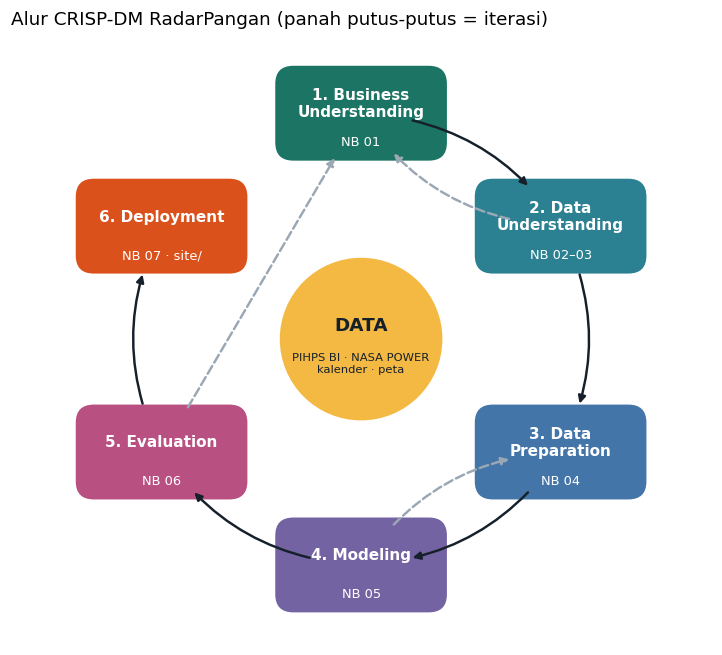

In [3]:
from matplotlib.patches import FancyBboxPatch, Circle
fig, ax = plt.subplots(figsize=(9, 7.2))
ax.set_xlim(-1.55, 1.55); ax.set_ylim(-1.35, 1.35); ax.axis("off"); ax.set_aspect("equal")
phases = [("1. Business\nUnderstanding", "NB 01"), ("2. Data\nUnderstanding", "NB 02–03"),
          ("3. Data\nPreparation", "NB 04"), ("4. Modeling", "NB 05"),
          ("5. Evaluation", "NB 06"), ("6. Deployment", "NB 07 · site/")]
ang = np.deg2rad([90, 30, -30, -90, -150, 150])
pos = [(np.cos(a) * 1.02, np.sin(a) * 1.0) for a in ang]
colors = ["#0f6e5c", "#1f7a8c", "#3a6ea5", "#6c5b9e", "#b5467b", "#d9480f"]
for (label, nb), (x, y), c in zip(phases, pos, colors):
    ax.add_patch(FancyBboxPatch((x - .36, y - .19), .72, .38, boxstyle="round,pad=0.02,rounding_size=0.08",
                                fc=c, ec="none", alpha=.95))
    ax.text(x, y + .04, label, ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    ax.text(x, y - .13, nb, ha="center", va="center", color="white", fontsize=8.5)
def arrow(i, j, rad=-0.25, style="-|>", color="#16202a", lw=1.6, ls="-"):
    ax.annotate("", xy=pos[j], xytext=pos[i], arrowprops=dict(arrowstyle=style, color=color, lw=lw, ls=ls,
                shrinkA=34, shrinkB=34, connectionstyle=f"arc3,rad={rad}"))
for i in range(5):
    arrow(i, i + 1)
arrow(1, 0, rad=-0.25, color="#9aa7b4", ls="--")   # iterasi: ambang lonjakan disesuaikan
arrow(3, 2, rad=-0.25, color="#9aa7b4", ls="--")   # iterasi: fitur/ablation
arrow(4, 0, rad=0.0, color="#9aa7b4", ls="--")     # evaluasi vs kriteria bisnis
ax.add_patch(Circle((0, 0), .36, fc="#f4b942", ec="none"))
ax.text(0, .06, "DATA", ha="center", va="center", fontsize=12, fontweight="bold", color="#16202a")
ax.text(0, -.11, "PIHPS BI · NASA POWER\nkalender · peta", ha="center", va="center", fontsize=7.5, color="#16202a")
ax.set_title("Alur CRISP-DM RadarPangan (panah putus-putus = iterasi)", fontsize=12, loc="left")
fig.savefig(P.figures / "fig_01_crisp_dm.png", dpi=180, bbox_inches="tight")
plt.show()

### Ringkasan fase 1
- **Masalah**: lonjakan harga pangan datang tiba-tiba, berbeda antarprovinsi, dan merambat; informasi yang ada hanya deskriptif.
- **Solusi**: RadarPangan — klasifikasi onset lonjakan 14 hari ke depan + jaringan rambatan antarprovinsi + sinyal margin rantai pasok, dijelaskan dengan SHAP, disajikan sebagai dashboard publik.
- **Kriteria sukses** sudah ditetapkan dan akan diperiksa di notebook 06.

➡️ Lanjut ke **`02_data_collection_scraping.ipynb`**.